<a href="https://colab.research.google.com/github/VozSoldat/PCVK-Ganjil-2025/blob/main/Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object detection

Metode yang digunakan:

1. Template matching
2. Edge detection
3. Corner detection
3. Grid detection
3. Contour detection

In [124]:
import cv2
import numpy
from matplotlib import pyplot as plt

In [125]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Template matching

In [126]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cats_and_bunnies.jpg', cv2.IMREAD_COLOR_BGR)
template = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/cat2_templatejpg.jpg', cv2.IMREAD_COLOR_BGR)
h, w = template.shape[:2] # Extract height and width from template shape

In [127]:
def show_bounding_box(res, img):
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    print(f"Top-left corner: {top_left}")
    print(f"Bottom-right corner: {bottom_right}")

    img_rgb = img.copy()
    cv2.rectangle(img_rgb, top_left, bottom_right, (0, 0, 255), 2)

    plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
    plt.title('Deteksi Template')
    plt.show()

In [128]:
def show_heatmap(res, cmap='gray'):
    plt.figure()
    plt.imshow(res, cmap=cmap)
    plt.colorbar()
    plt.show()

### SQDIFF

Top-left corner: (578, 86)
Bottom-right corner: (934, 535)


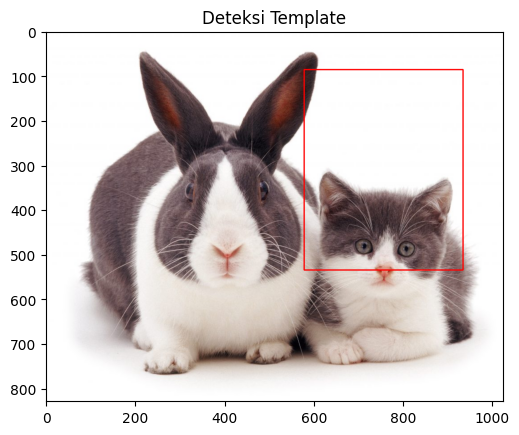

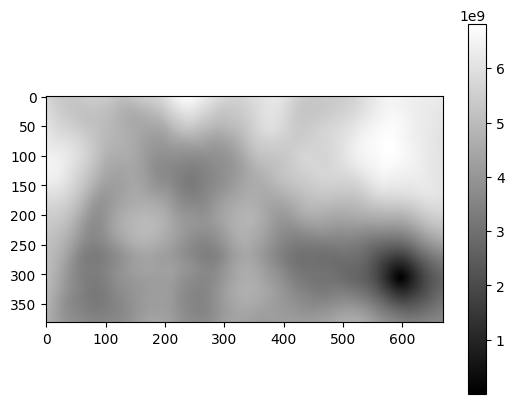

In [129]:
res = cv2.matchTemplate(img, template, cv2.TM_SQDIFF)

show_bounding_box(res, img)

show_heatmap(res)

### SQDIFF_NORMED

Top-left corner: (236, 0)
Bottom-right corner: (592, 449)


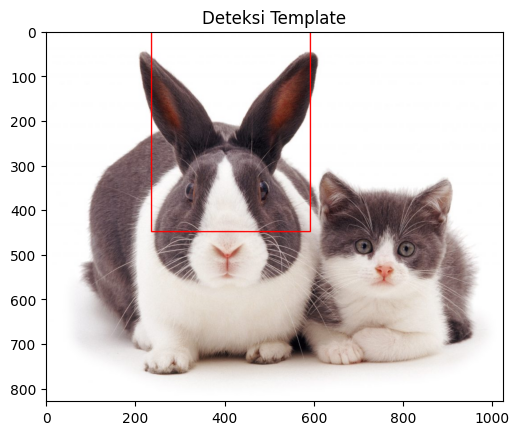

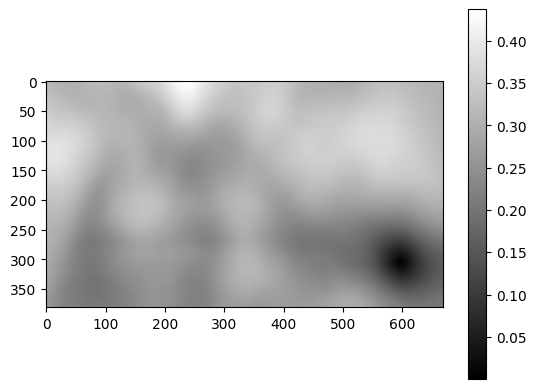

In [130]:
res = cv2.matchTemplate(img, template, cv2.TM_SQDIFF_NORMED)
show_bounding_box(res, img)
show_heatmap(res)

### CCORR

Top-left corner: (668, 0)
Bottom-right corner: (1024, 449)


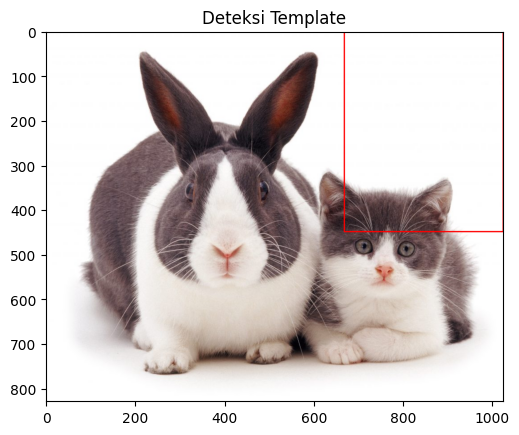

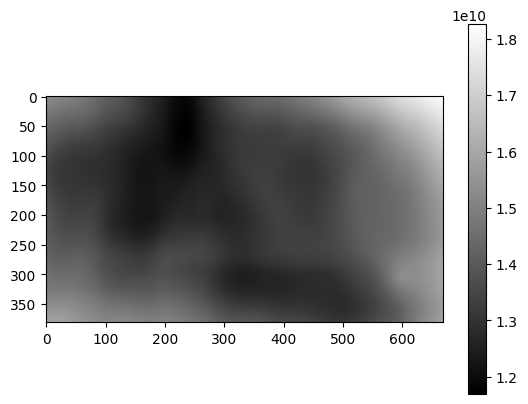

In [131]:
res = cv2.matchTemplate(img, template, cv2.TM_CCORR)
show_bounding_box(res, img)
show_heatmap(res)

Top-left corner: (597, 305)
Bottom-right corner: (953, 754)


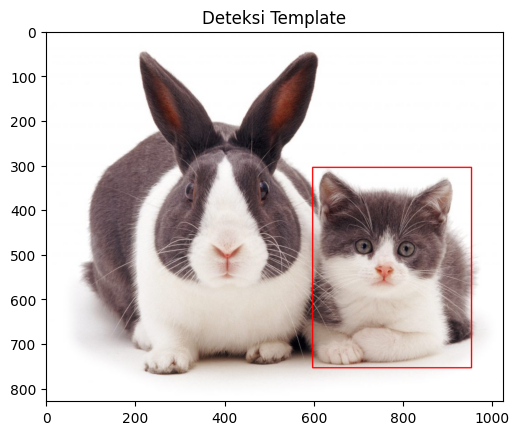

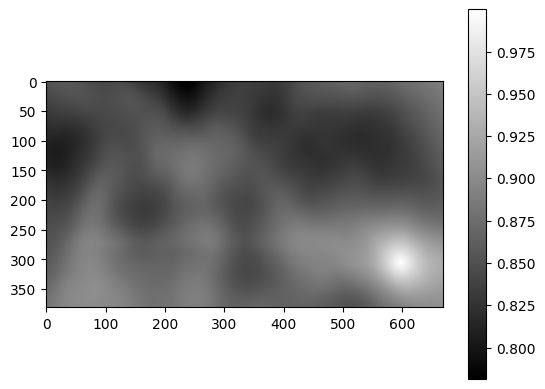

In [132]:
res = cv2.matchTemplate(img, template, cv2.TM_CCORR_NORMED)
show_bounding_box(res, img)
show_heatmap(res)

### COOEFF

Top-left corner: (597, 305)
Bottom-right corner: (953, 754)


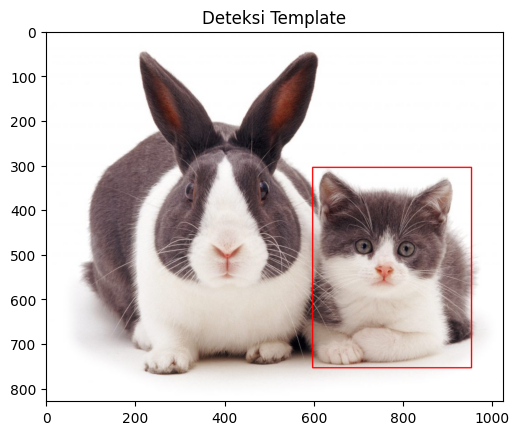

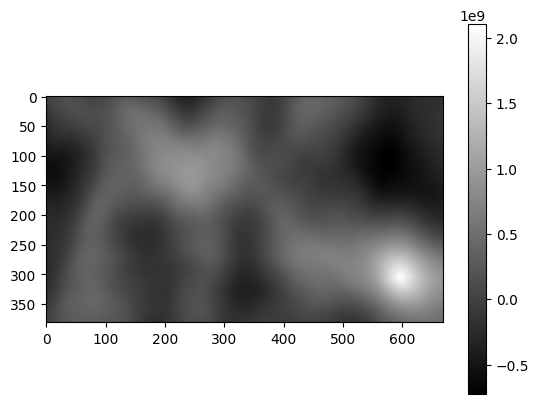

In [133]:
res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF)
show_bounding_box(res, img)
show_heatmap(res)

### COOEFF_NORMED

Top-left corner: (597, 305)
Bottom-right corner: (953, 754)


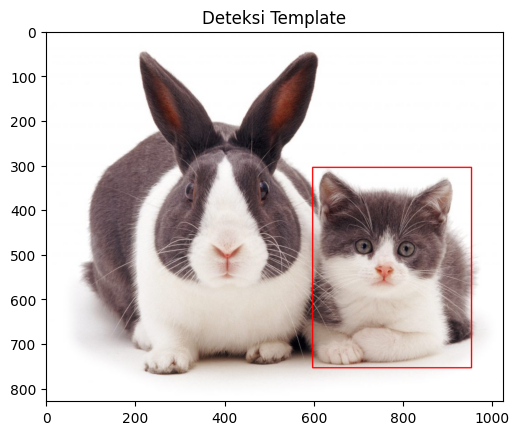

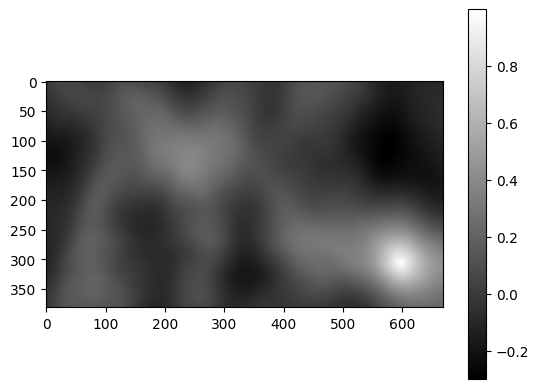

In [134]:
res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
show_bounding_box(res, img)
show_heatmap(res)

### Tanpa library OpenCV

Melakukan template matching sederhana tanpa OpenCV...
Skor terbaik: 0.9642
Posisi terbaik (x, y): (393, 204)


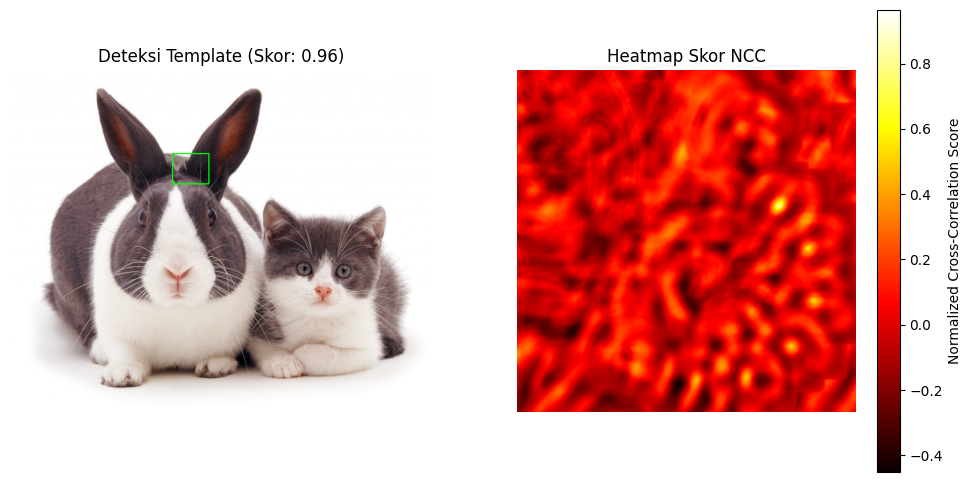

In [135]:
import numpy as np
import matplotlib.pyplot as plt

# Fungsi simple_template_match tanpa rotasi
def simple_template_match(image, template):
    """
    Template matching sederhana tanpa rotasi, menggunakan NCC.

    Args:
        image (ndarray): citra sumber (grayscale)
        template (ndarray): citra template (grayscale)

    Returns:
        dict: { 'best_score', 'best_pos', 'score_map', 'template_h', 'template_w' }
    """
    H, W = image.shape
    h_temp, w_temp = template.shape

    # Pastikan dimensi template lebih kecil atau sama dengan gambar
    if h_temp > H or w_temp > W:
        raise ValueError("Template dimensions must be smaller than or equal to image dimensions.")

    best_score = -1
    best_pos = (0, 0)

    score_map = np.zeros((H - h_temp + 1, W - w_temp + 1))

    for y in range(H - h_temp + 1):
        for x in range(W - w_temp + 1):
            patch = image[y:y+h_temp, x:x+w_temp]
            # Menggunakan normalized_cross_correlation yang sudah didefinisikan di sel sebelumnya
            score = normalized_cross_correlation(patch, template)
            score_map[y, x] = score
            if score > best_score:
                best_score = score
                best_pos = (x, y)

    return {
        'best_score': best_score,
        'best_pos': best_pos,
        'score_map': score_map,
        'template_h': h_temp,
        'template_w': w_temp
    }

# --- Fungsi pembantu untuk menampilkan hasil ---
# (Menggunakan OpenCV untuk display agar lebih mudah, bukan untuk logika matching)
def display_match_result(original_img, match_info):
    best_pos = match_info['best_pos']
    template_h = match_info['template_h']
    template_w = match_info['template_w']
    score_map = match_info['score_map']

    top_left = best_pos
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)

    img_display = original_img.copy()
    # Gambar persegi panjang pada gambar BGR asli
    cv2.rectangle(img_display, top_left, bottom_right, (0, 255, 0), 2) # Persegi hijau

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)) # Konversi BGR ke RGB untuk matplotlib
    plt.title(f'Deteksi Template (Skor: {match_info["best_score"]:.2f})')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(score_map, cmap='hot') # Menggunakan colormap 'hot' untuk score map
    plt.colorbar(label='Normalized Cross-Correlation Score')
    plt.title('Heatmap Skor NCC')
    plt.axis('off')

    plt.show()

# --- Demonstrasi penggunaan fungsi ---
# Menggunakan gambar dan template grayscale yang sudah dimuat sebelumnya
# img, img_gray, dan template_gray diharapkan sudah ada dari sel-sel sebelumnya

if 'img_gray' in locals() and 'template_gray' in locals() and 'img' in locals():
    print("Melakukan template matching sederhana tanpa OpenCV...")
    result_simple = simple_template_match(img_gray, template_gray)
    print(f"Skor terbaik: {result_simple['best_score']:.4f}")
    print(f"Posisi terbaik (x, y): {result_simple['best_pos']}")

    display_match_result(img, result_simple)

else:
    print("Variabel 'img_gray', 'template_gray', atau 'img' tidak ditemukan.")
    print("Pastikan sel-sel sebelumnya untuk memuat gambar ('bahrain.jpg' dan 'bahrain-template.jpg') telah dieksekusi.")

## Edge Detection

### Sobel

In [136]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/car-park.jpg')


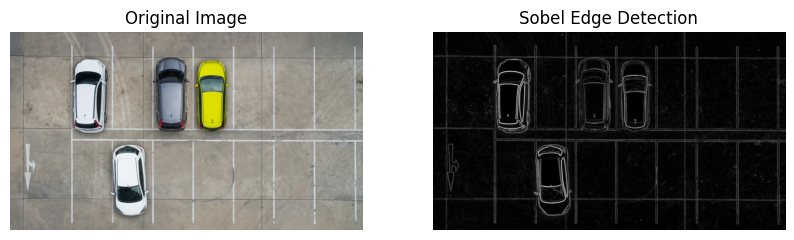

In [137]:
def sobel_edge_detection(image):
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Sobel filter in X direction
    sobelx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=5)
    # Apply Sobel filter in Y direction
    sobely = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=5)

    # Calculate the magnitude of the gradient
    magnitude = cv2.magnitude(sobelx, sobely)

    # Normalize to 0-255 for display
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    return magnitude


def show_edge_result (image, result):

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')


    plt.subplot(1, 2, 2)
    plt.imshow(result, cmap='gray')
    plt.title('Sobel Edge Detection')
    plt.axis('off')
    plt.show()



magnitude = sobel_edge_detection(img)
show_edge_result(img, magnitude)

### Canny Edge Detection

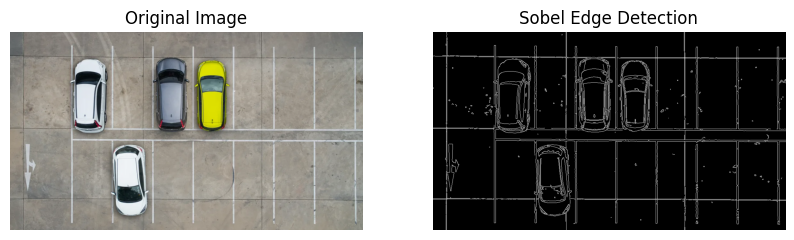

In [138]:
def canny_edge_detection(image, low_threshold=100, high_threshold=200):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray_image, low_threshold, high_threshold)

    return edges

# show_edge_result is already defined and can be reused
# It expects the original image and the edge result.

res = canny_edge_detection(img)
show_edge_result(img, res)

### Laplacian Edge Detection

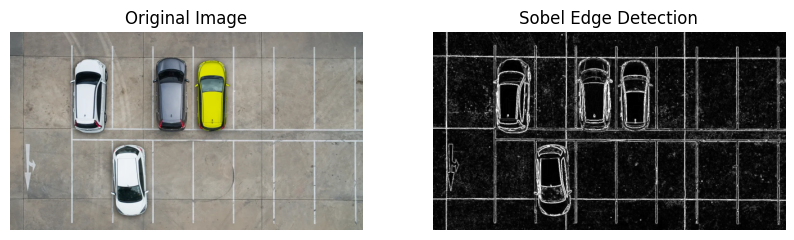

In [139]:
def laplacian_edge_detection(image, ksize=3):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    laplacian = cv2.Laplacian(gray_image, cv2.CV_64F, ksize=ksize)

    laplacian = cv2.convertScaleAbs(laplacian)

    return laplacian

res = laplacian_edge_detection(img)
show_edge_result(img, res)

## Corner Detection

In [140]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/chess-board.jpg')

### Harris Corner Detection

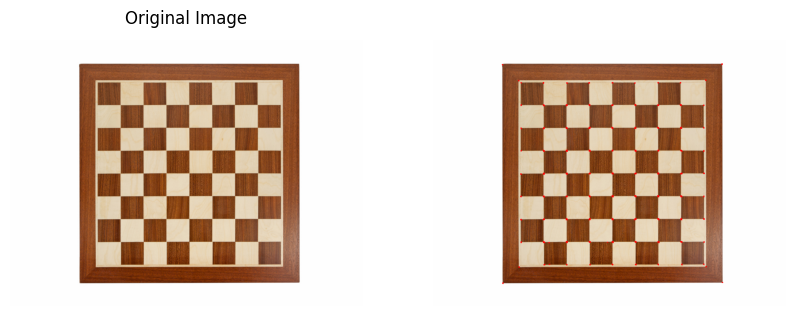

In [141]:
def harris_corner_detection(image, blockSize=2, ksize=3, k=0.04):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_image = np.float32(gray_image)

    dst = cv2.cornerHarris(gray_image, blockSize=blockSize, ksize=ksize, k=k)

    # Result is dilated for marking the corners
    dst = cv2.dilate(dst, None)

    return dst

def show_corner_result(original_image, corner_response):
    img_with_corners = original_image.copy()

    img_with_corners[corner_response > 0.01 * corner_response.max()] = [0, 0, 255]

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
    # plt.title('Harris Corners Detected')
    plt.axis('off')
    plt.show()

# Run Harris Corner Detection
harris_res = harris_corner_detection(img)
show_corner_result(img, harris_res)

### Shi-Tomashi

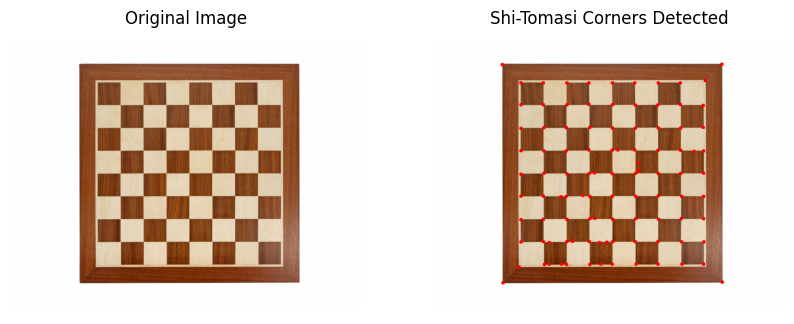

In [142]:
def shi_tomasi_corner_detection(image, maxCorners=100, qualityLevel=0.01, minDistance=10):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    corners = cv2.goodFeaturesToTrack(gray_image, maxCorners=maxCorners, qualityLevel=qualityLevel, minDistance=minDistance)

    corners = np.array(corners, dtype=np.intp)
    return corners

def show_shi_tomasi_corners(original_image, corners):
    img_with_corners = original_image.copy()

    if corners is not None:
        for i in corners:
            x, y = i.ravel()
            cv2.circle(img_with_corners, (int(x), int(y)), 5, [0, 0, 255], -1) # Draw a red circle at each corner

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
    plt.title('Shi-Tomasi Corners Detected')
    plt.axis('off')
    plt.show()

# Run Shi-Tomasi Corner Detection
shi_tomasi_res = shi_tomasi_corner_detection(img)
show_shi_tomasi_corners(img, shi_tomasi_res)

## Hough Transform

In [143]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/sudoku.jpg')

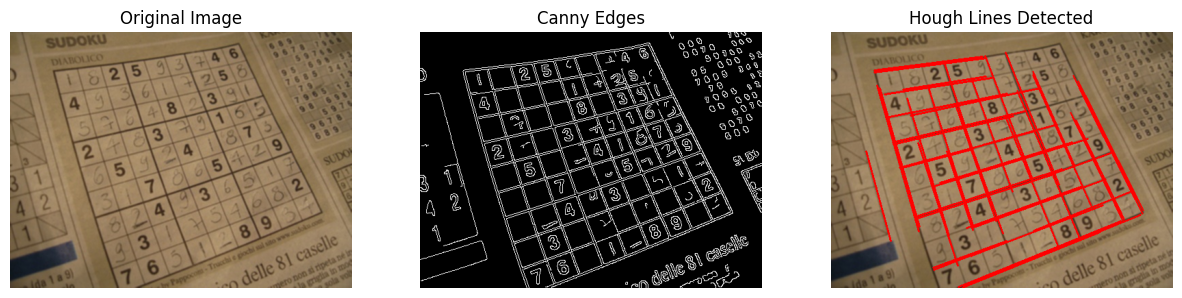

In [144]:
def hough_line_transform(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    edges = canny_edge_detection(image)
    # edges = shi_tomasi_corner_detection(image)

    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

    # Create a copy of the original image to draw lines on
    img_with_lines = image.copy()

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

    return edges, img_with_lines

edges, img_with_hough_lines = hough_line_transform(img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_with_hough_lines, cv2.COLOR_BGR2RGB))
plt.title('Hough Lines Detected')
plt.axis('off')

plt.show()

## Contour

In [145]:
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/Object Detection/laptop.jpg')

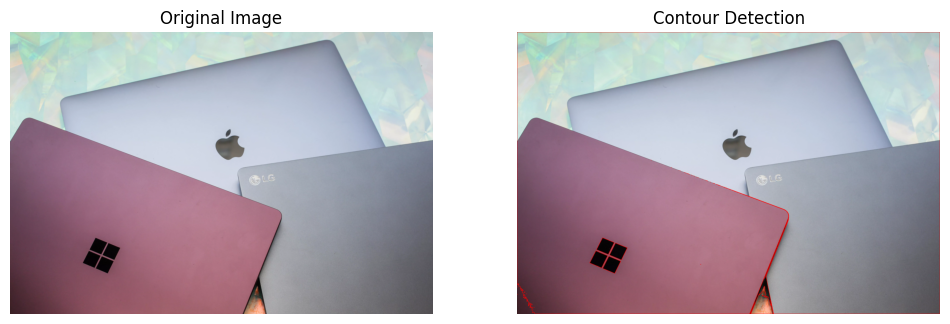

In [146]:
def contour_detection(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    img_with_contours = image.copy()

    cv2.drawContours(img_with_contours, contours, -1, (0, 0, 255), 2) # Green contours with thickness 2

    return img_with_contours




img_with_contours = contour_detection(img)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
plt.title('Contour Detection')
plt.axis('off')

plt.show()

# Feature Matching dan Face Detection

In [147]:
jokowi = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/jokowi.jpg')
kartini = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/kartini.jpg')
kucing = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/kucing.jpg')
masker = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/mask.png')
mjordan = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/mjordan.jpg')
solvayconf = cv2.imread('/content/drive/MyDrive/PCVK/Images/facedet/solvayconf.jpg')

prabowo = cv2.imread('/content/drive/MyDrive/PCVK/Images/prabowo.jpg')

In [148]:
def viola_jones_face_detection(image):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    img_with_faces = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_with_faces, (x, y), (x+w, y+h), (0, 255, 0), 2) # Green rectangle

    return img_with_faces

def show_face(image):
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


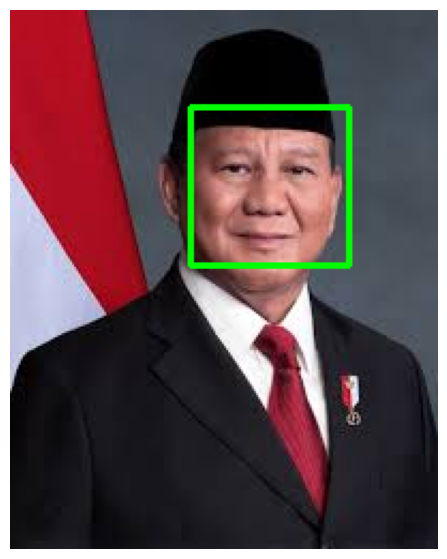

In [149]:
# jokowi_f = viola_jones_face_detection(jokowi)
# show_face(jokowi_f)

show_face(viola_jones_face_detection(prabowo))

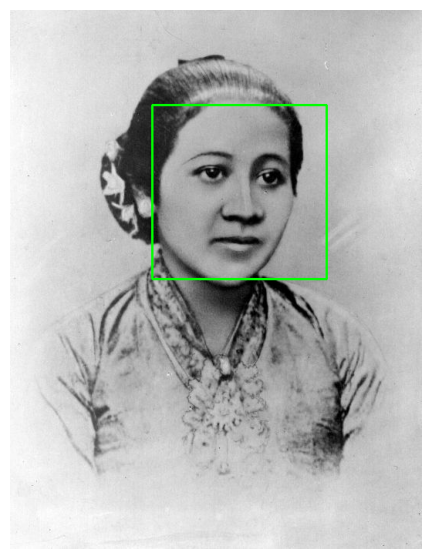

In [150]:
kartini_f = viola_jones_face_detection(kartini)
show_face(kartini_f)

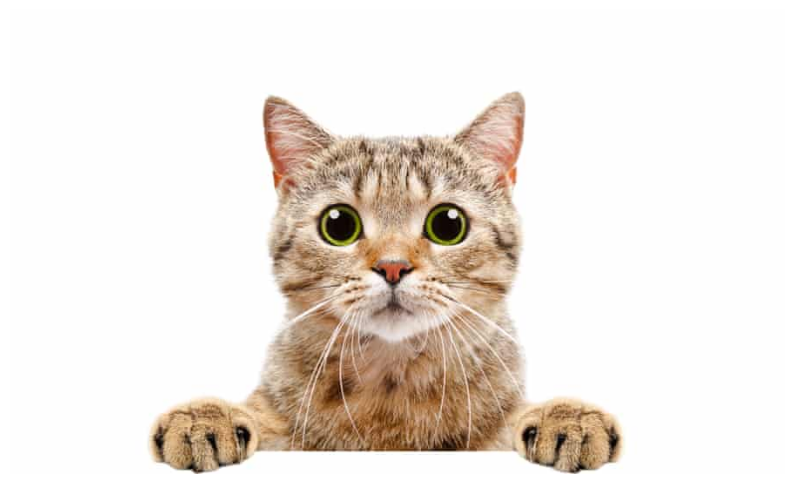

In [151]:
kucing_f = viola_jones_face_detection(kucing)
show_face(kucing_f)

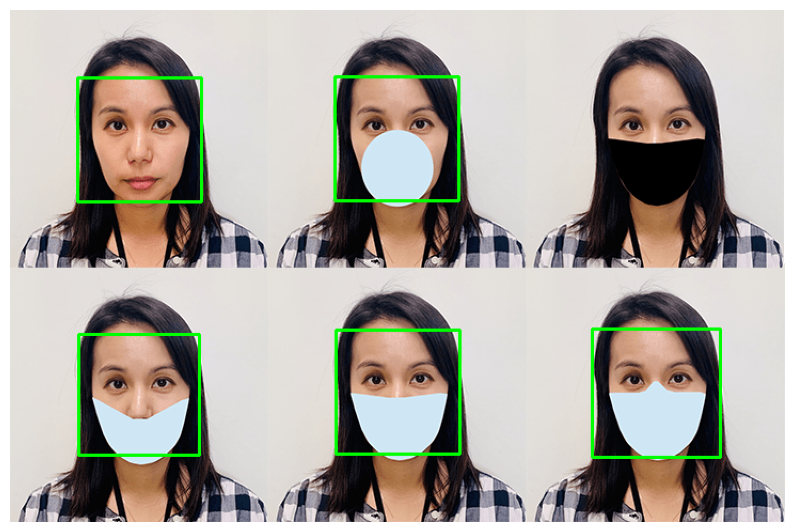

In [152]:
masker_f = viola_jones_face_detection(masker)
show_face(masker_f)

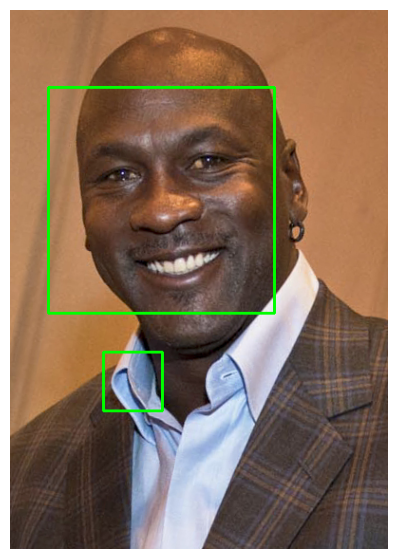

In [153]:
mjordan_f = viola_jones_face_detection(mjordan)
show_face(mjordan_f)

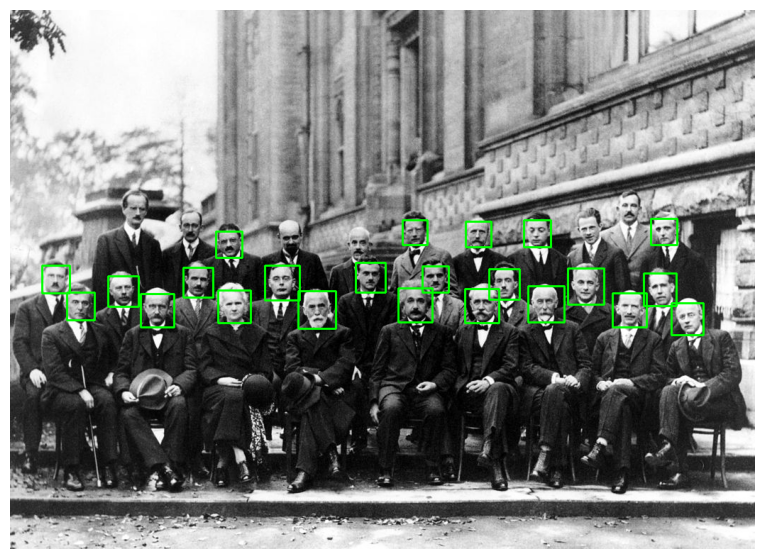

In [154]:
conf = viola_jones_face_detection(solvayconf)
show_face(conf)

## Modifikasi untuk wajah koceng

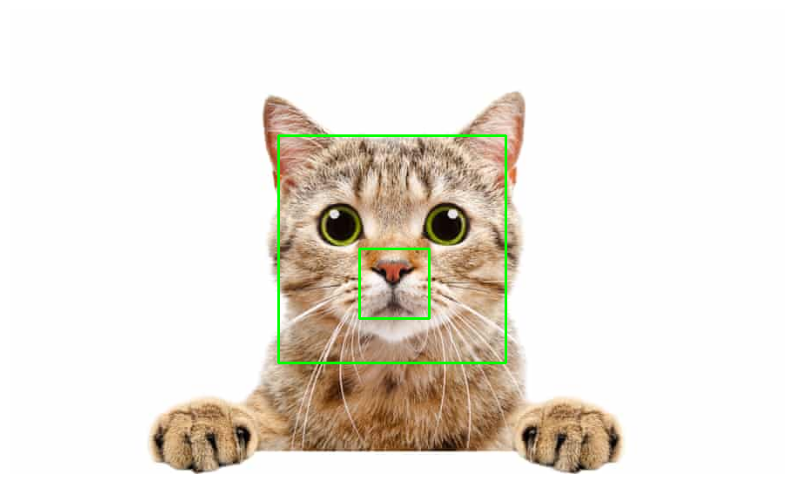

In [155]:
def cat_viola_jones_face_detection(image):
    # Load the cat face cascade classifier
    cat_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalcatface.xml')

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect cat faces in the image
    faces = cat_face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    img_with_faces = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_with_faces, (x, y), (x+w, y+h), (0, 255, 0), 2) # Green rectangle

    return img_with_faces

# Re-run cat face detection with the updated function
kucing_f = cat_viola_jones_face_detection(kucing)
show_face(kucing_f)

## Mata pak jokowi

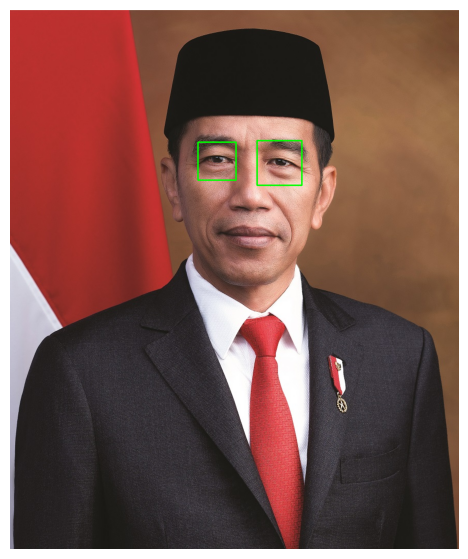

In [158]:
def viola_jones_eyes_detection(image):
    # Load the cat face cascade classifier
    cat_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect cat faces in the image
    faces = cat_face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    img_with_faces = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_with_faces, (x, y), (x+w, y+h), (0, 255, 0), 2) # Green rectangle

    return img_with_faces

mata_f = viola_jones_eyes_detection(jokowi)
show_face(mata_f)

## Deteksi senyuman

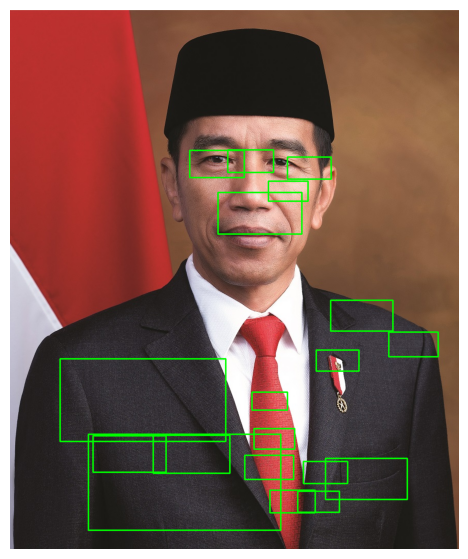

In [163]:
def viola_jones_smile_detection(image):
    # Load the cat face cascade classifier
    cat_face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = cat_face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    img_with_faces = image.copy()
    for (x, y, w, h) in faces:
        cv2.rectangle(img_with_faces, (x, y), (x+w, y+h), (0, 255, 0), 2) # Green rectangle

    return img_with_faces

show_face(viola_jones_smile_detection(jokowi))

## Blurring

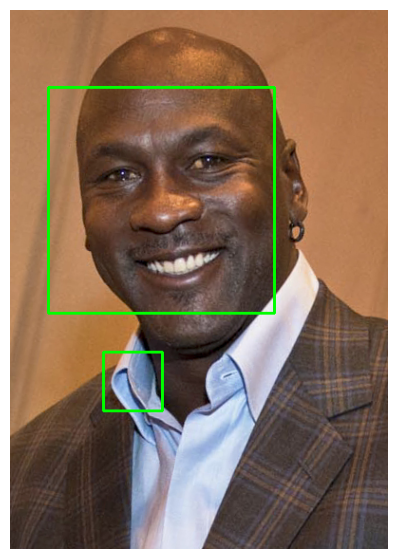

In [166]:
face = viola_jones_face_detection(mjordan)

show_face(face)

In [169]:
def viola_jones_face_detection_with_blur(image, kernel_size=21):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    img_with_blurred_faces = image.copy()
    for (x, y, w, h) in faces:
        face_roi = img_with_blurred_faces[y:y+h, x:x+w]

        blurred_face_roi = cv2.medianBlur(face_roi, kernel_size)

        img_with_blurred_faces[y:y+h, x:x+w] = blurred_face_roi

    return img_with_blurred_faces

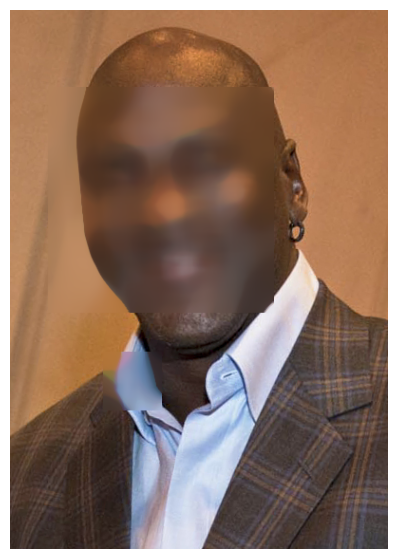

In [170]:
# Apply the new blur function to the mjordan image
mjordan_blurred_faces = viola_jones_face_detection_with_blur(mjordan, kernel_size=35)

# Display the result
show_face(mjordan_blurred_faces)

## Mengolah KTM

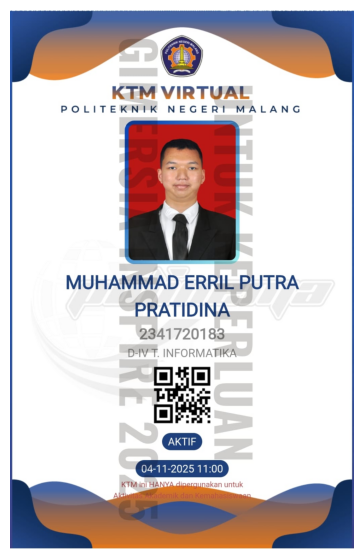

In [173]:
ktm = cv2.imread('/content/drive/MyDrive/PCVK/erril-ktm.jpeg')

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(ktm, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

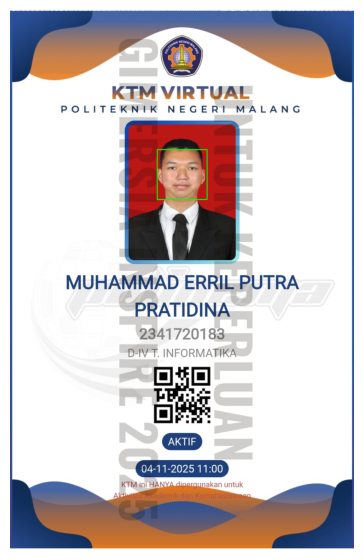

In [174]:
show_face(viola_jones_face_detection(ktm))